In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

In [3]:
df = pd.read_csv("../data/sample_car_contracts.csv")
df.head()

,id,customer_name,contract_type,vehicle_type,monthly_emi,interest_rate,tenure_months,clause_summary,risk_flag,issue_type,recommended_action
0,1,Rahul Mehta,Car Loan,Sedan,18500,9.5,48,Prepayment allowed only after 24 months with 5...,medium,High prepayment charges,Highlight prepayment penalty to user and sugge...
1,2,Anita Rao,Car Lease,SUV,22000,0.0,36,Lessee must pay for all maintenance and insurance,low,Standard maintenance clause,"No action, just explain maintenance responsibi..."
2,3,James Wilson,Car Loan,Hatchback,14500,11.2,60,Late payment fee of 3% per month on outstandin...,high,Aggressive late fee,Flag clause and suggest user request cap on la...
3,4,Meena Iyer,Car Lease,Sedan,21000,0.0,24,"Excess mileage charge of ₹12 per km over 15,00...",medium,High excess mileage rate,Warn user about extra mileage charges and reco...
4,5,Arjun Patel,Car Loan,SUV,27500,10.8,72,Floating interest rate linked to lender's inte...,high,Unclear interest benchmark,Explain floating rate risk and suggest asking ...


In [25]:
df.columns

Index(['id', 'customer_name', 'contract_type', 'vehicle_type', 'monthly_emi',
       'interest_rate', 'tenure_months', 'clause_summary', 'risk_flag',
       'issue_type', 'recommended_action'],
      dtype='object')

In [26]:
df['contract_length'] = df['clause_summary'].astype(str).apply(lambda x: len(x.split()))
df[['customer_name', 'clause_summary', 'contract_length']].head()

,customer_name,clause_summary,contract_length
0,Rahul Mehta,Prepayment allowed only after 24 months with 5...,9
1,Anita Rao,Lessee must pay for all maintenance and insurance,8
2,James Wilson,Late payment fee of 3% per month on outstandin...,10
3,Meena Iyer,"Excess mileage charge of ₹12 per km over 15,00...",12
4,Arjun Patel,Floating interest rate linked to lender's inte...,8


In [5]:
# keywords = ['fee', 'penalty', 'late', 'extra']

# df['hidden_charges_flag'] = df['clause_summary'].str.lower().apply(
#     lambda x: 1 if any(word in x for word in keywords) else 0
# )
# df[["clause_summary", "hidden_charges_flag"]]

In [10]:
#Data Cleaning and Preprocessing
import re
df['clean_text'] = df['clause_summary'].astype(str).str.lower()
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'\d+', '', x))    #    
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))    
df['clean_text'] = df['clean_text'].apply(lambda x: x.strip())                    


In [11]:
keywords = ['fee', 'penalty', 'late', 'extra']

df['hidden_charges_flag'] = df['clause_summary'].str.lower().apply(
    lambda x: True if any(word in x for word in keywords) else False
)
df[["clause_summary", "hidden_charges_flag"]]


,clause_summary,hidden_charges_flag
0,Prepayment allowed only after 24 months with 5...,True
1,Lessee must pay for all maintenance and insurance,False
2,Late payment fee of 3% per month on outstandin...,True
3,"Excess mileage charge of ₹12 per km over 15,00...",False
4,Floating interest rate linked to lender's inte...,False
5,Early termination fee equal to 6 months of EMI,True
6,No foreclosure charges after 12 months,False
7,Battery warranty covered only for 24 months or...,False
8,Mandatory bundled insurance from lender at non...,False
9,"Security deposit of 3 EMIs, refundable at end ...",False


In [ ]:
from collections import Counter

high = df[df["risk_flag"] == "high"]

text = " ".join(high["clause_summary"].astype(str))
words = text.split()

stop = ["the","a","and","in","for","to","of","is","on","with","per","only",
        "that","this","by","as","are","be"]

cleaned_words = [w for w in words if w not in stop]

top_words = Counter(cleaned_words).most_common(15)
top_words

[('fee', 2),
 ('Late', 1),
 ('payment', 1),
 ('3%', 1),
 ('month', 1),
 ('outstanding', 1),
 ('amount', 1),
 ('Floating', 1),
 ('interest', 1),
 ('rate', 1),
 ('linked', 1),
 ("lender's", 1),
 ('internal', 1),
 ('benchmark', 1),
 ('Early', 1)]

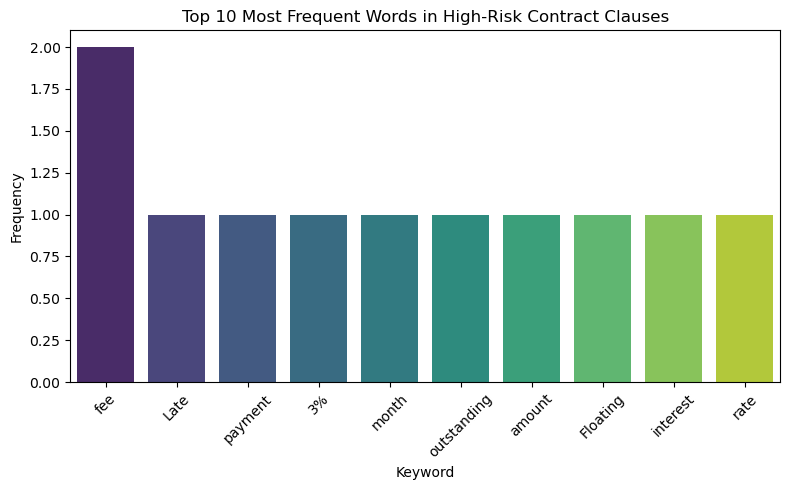

In [ ]:
top_words = Counter(cleaned_words).most_common(10)

top_df = pd.DataFrame(top_words, columns=["word", "count"])

plt.figure(figsize=(8,5))
sns.barplot(
    data=top_df,
    x="word",
    y="count",
    hue="word",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Most Frequent Words in High-Risk Contract Clauses")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
